In [1]:
import diplib as dip
import os

DIPlib -- a quantitative image analysis library
Version 3.5.2 (Jan 28 2025)
For more information see https://diplib.org


In [2]:
image = dip.ImageRead("/home/mrajaraman/dataset/annotated/a_img_931176390-labels.tif")

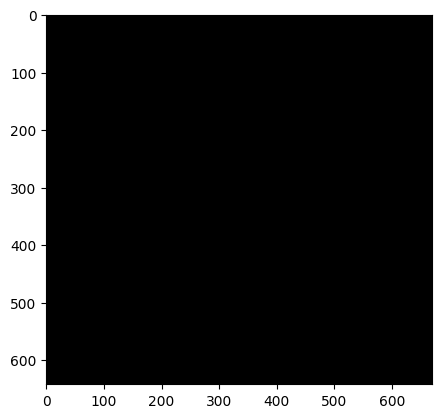

In [3]:
image.Show()

In [5]:
dip.ImageWritePNG(image, "/home/mrajaraman/img_931176390.png")

# Time for CSV

In [1]:
import pandas as pd

In [22]:
files = pd.read_csv("/home/mrajaraman/dataset/files.txt",sep="\t", header=None)

In [16]:
type(files)

pandas.core.frame.DataFrame

In [23]:
popped_rows = files.iloc[:4].copy()
files = files.iloc[4:]

In [25]:
popped_rows = files.tail(3).copy()
files = files.iloc[:-3]

In [27]:
files = files.reset_index(drop=True)

In [31]:
files.columns = ["id"]

In [32]:
files['id'] = files['id'].str.replace('img_','')

In [33]:
files['id'] = files['id'].str.replace('.jpg','')

In [37]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
distutils: /home/mrajaraman/.local/lib/python3.9/site-packages
sysconfig: /home/mrajaraman/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None


In [39]:
import sklearn

ModuleNotFoundError: No module named 'sklearn'

In [38]:
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'sklearn'

In [ ]:

#split the data into train and test set
train,test = train_test_split(files, test_size=0.30, random_state=0)
#save the data
# train.to_csv('train.csv',index=False)
test.to_csv('test.csv',index=False)

ModuleNotFoundError: No module named 'sklearn'

In [34]:
print(files)

               id
0      1036449121
1      1036449136
2      1036487309
3      1036502930
4      1036503439
...           ...
12897   997994886
12898   998017453
12899   998017841
12900   998025140
12901   998027221

[12902 rows x 1 columns]


In [12]:
files.pop(0)

KeyError: 0

In [2]:
import torch

pth_path = "/home/mrajaraman/Code/model_checkpoints/model_final_mask_rcnn.pth"

# Safely load the checkpoint with weights_only=False
checkpoint = torch.load(pth_path, weights_only=False, map_location='cpu')

# Check type and keys if it's a dict
if isinstance(checkpoint, dict):
    print("Checkpoint Keys:", checkpoint.keys())

    # Optionally inspect details
    for key in checkpoint:
        print(f"Key: {key}, Type: {type(checkpoint[key])}")
        if isinstance(checkpoint[key], dict):
            print(f"  Nested Keys: {checkpoint[key].keys()}")
else:
    print("Checkpoint is not a dict. It's type:", type(checkpoint))


ModuleNotFoundError: No module named 'omegaconf'

# Combining the images

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# un_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/testing-batch.csv")
# an_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/results-and-images/yolo/unseen_inference_testing/testing_batch/list.csv")

un_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/camouflaged.csv")
an_df = pd.read_csv("/home/mrajaraman/master-thesis-dragonfly/results-and-images/yolo/unseen_inference_testing/camo_batch/list.csv")

unannotated_images = un_df['Path'].tolist()
annotated_images = an_df['Path'].tolist()

In [6]:
unan = unannotated_images[:3]
anan = annotated_images[:3]

In [7]:
for i, (un_path, an_path) in enumerate(zip(unannotated_images, annotated_images)):
    un_img = plt.imread(un_path)
    an_img = plt.imread(an_path)
    
    # Create a side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(20, 12))
    axes[0].imshow(un_img)
    axes[0].set_title('Unannotated Image', fontsize=24)
    axes[0].axis('off')
    
    axes[1].imshow(an_img)
    axes[1].set_title('Annotated Image', fontsize=24)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"annotated_vs_unannotated_{i}.png", bbox_inches='tight', pad_inches=0.2)
    plt.close()

In [3]:
import os

output_dir = "saved_images"
os.makedirs(output_dir, exist_ok=True)

In [4]:
import os
import matplotlib.pyplot as plt

# Ensure the output folder exists
output_dir = "saved_images"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
import os
from PIL import Image, ImageDraw, ImageFont

# === Setup ===
output_dir = "saved_images"
os.makedirs(output_dir, exist_ok=True)

# # Load a font
# try:
#     font = ImageFont.truetype("arial.ttf", 64)
# except OSError:
#     font = ImageFont.load_default()

font = ImageFont.truetype("arial.ttf", 64)

def get_text_size(draw, text, font):
    """Helper function compatible with all Pillow versions."""
    try:
        # Newer Pillow (>=10)
        bbox = draw.textbbox((0, 0), text, font=font)
        width, height = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except AttributeError:
        # Older Pillow (<10)
        width, height = draw.textsize(text, font=font)
    return width, height


for i, (un_path, an_path) in enumerate(zip(unannotated_images, annotated_images)):
    # Load images
    un_img = Image.open(un_path).convert("RGB")
    an_img = Image.open(an_path).convert("RGB")

    # Reserve space for titles
    title_height = 100
    total_width = un_img.width + an_img.width
    max_height = max(un_img.height, an_img.height) + title_height

    # Create blank white canvas
    new_img = Image.new("RGB", (total_width, max_height), color=(255, 255, 255))
    new_img.paste(un_img, (0, title_height))
    new_img.paste(an_img, (un_img.width, title_height))

    # Draw text
    draw = ImageDraw.Draw(new_img)
    un_text = "Unannotated Image"
    an_text = "Annotated Image"

    un_text_width, un_text_height = get_text_size(draw, un_text, font)
    an_text_width, an_text_height = get_text_size(draw, an_text, font)

    # Center titles above each image
    draw.text(
        ((un_img.width - un_text_width) // 2, (title_height - un_text_height) // 2),
        un_text, fill="black", font=font
    )
    draw.text(
        (un_img.width + (an_img.width - an_text_width) // 2, (title_height - an_text_height) // 2),
        an_text, fill="black", font=font
    )

    # Save
    save_path = os.path.join(output_dir, f"annotated_vs_unannotated_{i}.png")
    new_img.save(save_path)
    print(f"✅ Saved: {save_path}")


OSError: cannot open resource

In [7]:
import json
import os

def merge_coco_jsons(json1_path, json2_path, output_path):
    with open(json1_path) as f:
        coco1 = json.load(f)
    with open(json2_path) as f:
        coco2 = json.load(f)

    img_offset = max(img["id"] for img in coco1["images"]) + 1
    ann_offset = max(ann["id"] for ann in coco1["annotations"]) + 1

    for img in coco2["images"]:
        img["id"] += img_offset
    for ann in coco2["annotations"]:
        ann["id"] += ann_offset
        ann["image_id"] += img_offset

    merged = {
        "images": coco1["images"] + coco2["images"],
        "annotations": coco1["annotations"] + coco2["annotations"],
        "categories": coco1["categories"],  # must match
    }

    with open(output_path, "w") as f:
        json.dump(merged, f)

json1_path = "/home/mrajaraman/dataset/coco/annotations/instances_val.json"
json2_path = "/home/mrajaraman/dataset/coco-newer/annotations/instances_val.json"
output_path = "/home/mrajaraman/temp_datasets/instances_val.json"

merge_coco_jsons(json1_path, json2_path, output_path)